# House Price Regression — Phase 2: Feature Engineering
Ames Housing Dataset

In [1]:
# import necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
 

In [2]:
# Load Data

df = pd.read_csv("AmesHousing.csv")

df['LogSalePrice'] = np.log1p(df['SalePrice'])

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 2930 rows × 83 columns


# Handling missing values for both Categorical and Numerical data

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
# Missing values for Categorical Columns
# The None_Cats Variable stores columns without a category that will be filled with None
 
NONE_CATS = ["Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu",
             "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
             "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1",
             "BsmtFin Type 2", "Mas Vnr Type"]

# The Zero_Num caraibales stores columns without a category that will filled with Zero (0)

ZERO_NUMS = ["Garage Yr Blt", "Garage Area", "Garage Cars",
             "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF",
             "Bsmt Full Bath", "Bsmt Half Bath", "Mas Vnr Area"]
 
for col in NONE_CATS:
    if col in df.columns:
        df[col] = df[col].fillna("None")
 
for col in ZERO_NUMS:
    if col in df.columns:
        df[col] = df[col].fillna(0)
 

if "LotFrontage" in df.columns:
    df["LotFrontage"] = df.groupby("Neighborhood")["Lot Frontage"].transform(lambda x: x.fillna(x.median()))

# 4. Fallback: Fill any remaining categorical columns with their mode
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Fallback: Fill any remaining numeric columns with their median (just in case)
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Verification
missing_left = df.isnull().sum().sum()
print(f"Missing values remaining: {missing_left} (should be 0)")


Missing values remaining: 0 (should be 0)


# Creating New Features from existing Features

In [8]:
 # Total above-ground living area (combines all floors + basement)
df["TotalSF"] = df["Total Bsmt SF"] + df["1st Flr SF"] + df["2nd Flr SF"]
 
# Age-related features
df["HouseAge"]   = df["Yr Sold"] - df["Year Built"]
df["RemodAge"]   = df["Yr Sold"] - df["Year Remod/Add"]
df["IsRemodeled"] = (df["Year Built"] != df["Year Remod/Add"]).astype(int)
 
# Total bathrooms (full counts double a half bath)
df["TotalBaths"] = (df["Full Bath"] + df["Bsmt Full Bath"]
                    + 0.5 * (df["Half Bath"] + df["Bsmt Half Bath"]))
 
# Porch area combined
df["TotalPorchSF"] = (df["Open Porch SF"] + df["Enclosed Porch"]
                      + df["3Ssn Porch"]  + df["Screen Porch"])
 
# Has pool / has garage flags (binary)
df["HasPool"]    = (df["Pool Area"] > 0).astype(int)
df["HasGarage"]  = (df["Garage Area"] > 0).astype(int)
df["Has2ndFloor"] = (df["2nd Flr SF"] > 0).astype(int)
 
NEW_FEATURES = ["TotalSF", "HouseAge", "RemodAge", "IsRemodeled",
                "TotalBaths", "TotalPorchSF", "HasPool", "HasGarage", "Has2ndFloor"]
 
print(f"\nNew features created: {NEW_FEATURES}")


New features created: ['TotalSF', 'HouseAge', 'RemodAge', 'IsRemodeled', 'TotalBaths', 'TotalPorchSF', 'HasPool', 'HasGarage', 'Has2ndFloor']


# Correlation of new features with LogSalePrice

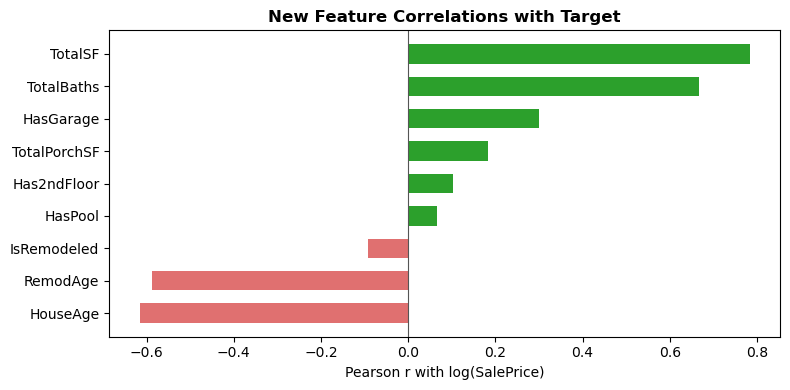

In [9]:
new_corr = df[NEW_FEATURES + ["LogSalePrice"]].corr()["LogSalePrice"].drop("LogSalePrice").sort_values()
 
fig, ax = plt.subplots(figsize=(8, 4))
# sns.heatmap(new_corr,  fmt=".2f", ax=ax)
colors = ["#2ca02c" if v > 0 else "#E07070" for v in new_corr]
ax.barh(new_corr.index, new_corr.values, color=colors, height=0.6)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel("Pearson r with log(SalePrice)")
ax.set_title("New Feature Correlations with Target", fontweight="bold")
plt.tight_layout()
plt.savefig("phase2_new_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

# ENCODE CATEGORICAL FEATURES

In [10]:
# Ordinal features — meaningful quality order (Po < Fa < TA < Gd < Ex)
QUALITY_ORDER  = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
ORDINAL_COLS   = ["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
                  "Heating QC", "Kitchen Qual", "Fireplace Qu",
                  "Garage Qual", "Garage Cond", "Pool QC"]
 
# Garage finish: no garage → unfinished → rough → finished
GARAGE_FINISH_ORDER = ["None", "Unf", "RFn", "Fin"]
 
# Basement exposure: no basement → no exposure → minimal → average → good
BSMT_EXP_ORDER = ["None", "No", "Mn", "Av", "Gd"]
 
# Fence quality
FENCE_ORDER    = ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"]

In [12]:
for col in ORDINAL_COLS:
    if col in df.columns:
        df[col] = pd.Categorical(df[col], categories=QUALITY_ORDER, ordered=True).codes
 
df["Garage Finish"] = pd.Categorical(df["Garage Finish"],
                                     categories=GARAGE_FINISH_ORDER, ordered=True).codes
df["Bsmt Exposure"]  = pd.Categorical(df["Bsmt Exposure"],
                                     categories=BSMT_EXP_ORDER, ordered=True).codes
df["Fence"]         = pd.Categorical(df["Fence"],
                                     categories=FENCE_ORDER, ordered=True).codes
 
print("\nOrdinal encoding done. Sample (ExterQual):")
print(df["Exter Qual"].value_counts().sort_index().to_string())
 
# One-hot encode remaining nominal categoricals
nominal_cols = df.select_dtypes(include="object").columns.tolist()
print(f"\nNominal columns to one-hot encode ({len(nominal_cols)}): {nominal_cols}")
 
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f"Shape after one-hot encoding: {df.shape}")


Ordinal encoding done. Sample (ExterQual):
Exter Qual
-1    2930

Nominal columns to one-hot encode (30): ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Paved Drive', 'Misc Feature', 'Sale Type', 'Sale Condition']
Shape after one-hot encoding: (2930, 241)


# Selecting Final Features

In [ ]:
 # DROP COLUMNS NOT NEEDED FOR MODELLING

DROP_COLS = [
    "Order",           # just an index
    "SalePrice",    # use LogSalePrice as target
    "Year Built", "Year Remod/Add", "Yr Sold", "Mo Sold",  # replaced by age features
    "Garage Yr Blt",  # redundant with HouseAge
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
 
print(f"\nFinal feature count: {df.shape[1] - 1} features + 1 target")
 

 
df.to_csv("train_processed.csv", index=False)


Final feature count: 233 features + 1 target

Saved: train_processed.csv  ← load this in Phase 3 for modelling
